# RIM Spread Integrated Pipeline v2
## Re_smooth (Blume β + CAPM) + TTM ROE → rim_spread_smooth

### 처리 흐름
```
①  DB (us_stock_daily_market_cap, close_price) → SPY + 종목 주가 fetch
②  rolling 1260일 beta → Blume smoothing → β_adj = 0.67×β + 0.33×1.0
③  FRED API (DGS5)                           → rf_5y (daily ffill)
④  SPY 주가 rolling 1260일 CAGR              → E_Rm  (ERP floor 6% 적용)
⑤  CAPM: Re_smooth = rf + β_adj × max(E_Rm-rf, ERP_floor)
⑥  FMP API (분기 IS+BS)                      → TTM ROE (look-ahead bias 보정)
⑦  TTM ROE → 월말 ffill(limit=3)             → roe_monthly
⑧  rim_spread_smooth = roe_monthly − Re_smooth (월말 기준)
⑨  DB upsert: Re_smooth / beta_adj / roe_ttm / rim_spread_smooth
⑩  시각화: 4패널 차트 + 해자 분류 요약
```

### 저장 테이블
- **`us_rim_spread_data`** (date · ticker · indicator · value)

### 기존 테이블 (읽기 전용)
- `us_stock_daily_market_cap`  (indicator=`close_price`)

---
| 셀  | 역할 |
|-----|------|
| 1   | 경로 자동 감지 (노트북/데스크탑) |
| 2   | Import & 설정 상수 |
| 3   | DB 연결 & 테이블 초기화 |
| 4   | 주가 fetch 함수 |
| 5   | Beta 계산 함수 (rolling + Blume) |
| 6   | RF fetch (FRED DGS5) |
| 7   | Re_smooth 빌드 함수 |
| 8   | TTM ROE (FMP API) |
| 9   | Spread 계산 & 해자 분류 |
| 10  | DB 저장 유틸 (upsert & 증분) |
| 11  | 단일 티커 처리 파이프라인 |
| 12  | 배치 공통 데이터 준비 (1회 로드) |
| 13  | 배치 실행 |
| 14  | 시각화 함수 |
| 15  | 분석 실행 & DB 현황 조회 |


## Cell 1 · 경로 자동 감지

노트북/데스크탑 환경 모두 `DATA/` 폴더를 자동 탐지합니다.

In [1]:
import sys, os, gc, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ── 후보 프로젝트 루트 ─────────────────────────────────────────────
_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",         # 노트북
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",  # 데스크탑
]

def _setup_path() -> str:
    """DATA/ 폴더를 포함하는 프로젝트 루트를 탐색해 sys.path 에 추가."""
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()

    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root

    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] root 후보 경로 : {candidate}")
            return candidate

    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다.\n"
        "_CANDIDATE_ROOTS 를 현재 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")


[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정 상수

> **여기만 수정하면 됩니다:** `TICKER_START / TICKER_END / SKIP_DONE`

In [2]:
# ── 표준 라이브러리 ──────────────────────────────────────────────
import math, time, requests
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple
from pandas.tseries.offsets import BDay

# ── 외부 라이브러리 ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import pymysql
import FinanceDataReader as fdr
from IPython.display import display

# ── 내부 모듈 ────────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_2000 import ticker_list as US_TICKER_LIST

# ── 로그 유틸 ────────────────────────────────────────────────────
def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ══════════════════════════════════════════════════════════════════
#  설정 상수 — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════════
FMP_API_KEY  = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FRED_API_KEY = "81ada9c572f7d710dbc61f035556cbd7"

DB_NAME       = "investar"
TABLE_RESULT  = "us_rim_spread_data"          # ★ 신규 테이블
TABLE_PRICE   = "us_stock_daily_market_cap"
PRICE_IND     = "close_price"
DEFAULT_PORT  = 3307
MARKET_TICKER = "SPY"

# 롤링 파라미터 (5년 ≈ 1260 영업일)
ROLLING_WINDOW = 1260
ROLLING_WARMUP = ROLLING_WINDOW + 100   # fetch 시 여유 기간

# Blume smoothing
BLUME_W     = 0.67   # 원시 beta 가중치
ERP_FLOOR   = 0.06   # ERP 하한 6%
ERP_MIN_GAP = 0.01   # E_Rm - rf < 1% 이면 ERP_FLOOR 적용

# 데이터 품질 기준
MIN_PRICE_ROWS = 300
MAX_PRICE_GAP  = 30

# 배치 처리 범위 (필요 시 조정)
TICKER_START = 1000
TICKER_END   = 2000 #len(US_TICKER_LIST)
SKIP_DONE    = False   # True: 이미 처리된 티커 건너뜀

# 체크포인트
CHECKPOINT_DIR = "_rim_spread_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

# ── DB 접속 정보 ─────────────────────────────────────────────────
db_info = get_db_info()

print(f"[OK] Import 완료")
print(f"[OK] 대상 티커: {len(US_TICKER_LIST):,}개  (범위: [{TICKER_START}:{TICKER_END}])")
print(f"[설정] TABLE_RESULT={TABLE_RESULT}")
print(f"[설정] ROLLING_WINDOW={ROLLING_WINDOW}  BLUME_W={BLUME_W}  ERP_FLOOR={ERP_FLOOR}")


[OK] Import 완료
[OK] 대상 티커: 2,000개  (범위: [1000:2000])
[설정] TABLE_RESULT=us_rim_spread_data
[설정] ROLLING_WINDOW=1260  BLUME_W=0.67  ERP_FLOOR=0.06


## Cell 3 · DB 연결 & 테이블 초기화

- `us_rim_spread_data` 테이블 자동 생성 (없는 경우)
- `port = int(...)` 명시적 캐스팅으로 포트 오류 방지

In [3]:
# ── DB 연결 함수 ────────────────────────────────────────────────
def get_conn():
    """pymysql DictCursor 연결 생성"""
    return pymysql.connect(
        host       = db_info["host"],
        port       = int(db_info.get("port", DEFAULT_PORT)),  # ★ 명시적 int 캐스팅
        user       = db_info["user"],
        password   = db_info["password"],
        db         = db_info.get("database", DB_NAME),
        charset    = "utf8mb4",
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )

# ── 테이블 초기화 (없으면 자동 생성) ────────────────────────────
CREATE_SQL = """
CREATE TABLE IF NOT EXISTS `us_rim_spread_data` (
  `date`      DATE        NOT NULL,
  `ticker`    VARCHAR(20) NOT NULL,
  `indicator` VARCHAR(50) NOT NULL,
  `value`     DOUBLE      DEFAULT NULL,
  PRIMARY KEY (`date`, `ticker`, `indicator`),
  INDEX idx_ticker_indicator (`ticker`, `indicator`),
  INDEX idx_date (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
except Exception as e:
    conn.rollback()
    log("DB", f"테이블 생성 오류: {e}"); raise
finally:
    conn.close()

# ── 연결 테스트 ──────────────────────────────────────────────────
try:
    _c = get_conn()
    with _c.cursor() as _cur:
        _cur.execute("SELECT 1")
    _c.close()
    log("DB", f"연결 성공  host={db_info.get('host')}  port={db_info.get('port')}")
except Exception as _e:
    log("DB", f"연결 실패: {_e}")


[23:20:29][DB] 테이블 준비 완료: us_rim_spread_data
[23:20:29][DB] 연결 성공  host=192.168.0.230  port=3307


## Cell 4 · 주가 fetch 함수

- `cursor.execute()` → `fetchall()` → `pd.DataFrame()` 패턴 (`pd.read_sql` 사용 금지)
- SPY 는 DB 우선 → 없으면 FDR fallback
- 품질 검증: 최소 거래일, 최대 공백, 양수 가격 필터

In [4]:
# ─────────────────────────────────────────────────────────────────
# Cell 4 · 주가 fetch 함수
# ─────────────────────────────────────────────────────────────────

def fetch_price_from_db(
    ticker:     str,
    start_date: Optional[str] = None,
    end_date:   Optional[str] = None,
) -> pd.DataFrame:
    """
    us_stock_daily_market_cap 에서 close_price 시계열 조회.
    ★ cursor.execute → fetchall → pd.DataFrame 패턴 (pd.read_sql 사용 금지)
    반환: [date, price] (정렬됨)
    """
    where  = ["ticker = %s", "indicator = %s"]
    params: List[Any] = [ticker, PRICE_IND]
    if start_date:
        where.append("date >= %s"); params.append(start_date)
    if end_date:
        where.append("date <= %s"); params.append(end_date)

    sql = (f"SELECT date, value AS price FROM {TABLE_PRICE} "
           f"WHERE {' AND '.join(where)} ORDER BY date")

    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql, params)
            rows = cur.fetchall()
            df = pd.DataFrame(rows)        # ★ pd.read_sql 사용 안 함
    finally:
        conn.close()

    if df.empty:
        return pd.DataFrame(columns=["date", "price"])

    df["date"]  = pd.to_datetime(df["date"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = (df.dropna(subset=["date", "price"])
            .drop_duplicates("date")
            .sort_values("date")
            .reset_index(drop=True))
    return df


def validate_price_series(df: pd.DataFrame, ticker: str) -> Tuple[bool, str]:
    """주가 시계열 품질 검증. 반환: (True, 'OK') or (False, 사유)"""
    if df is None or df.empty:
        return False, f"{ticker}: 데이터 없음"
    if len(df) < MIN_PRICE_ROWS:
        return False, f"{ticker}: 거래일 수 부족 ({len(df)} < {MIN_PRICE_ROWS})"
    valid = df[df["price"] > 0]
    if len(valid) < MIN_PRICE_ROWS:
        return False, f"{ticker}: 유효 가격 부족 (양수 {len(valid)}개)"
    gaps = pd.to_datetime(df["date"]).sort_values().diff().dt.days.dropna()
    if gaps.max() > MAX_PRICE_GAP:
        return False, f"{ticker}: 최대 날짜 공백 {int(gaps.max())}일"
    return True, "OK"


def fetch_fdr_price_fallback(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    """FinanceDataReader fallback (SPY 등 DB 에 없을 때)"""
    try:
        df = fdr.DataReader(symbol, start_date, end_date)
    except Exception:
        return pd.DataFrame(columns=["date", "price"])
    if df is None or df.empty:
        return pd.DataFrame(columns=["date", "price"])

    df = df.copy().reset_index()
    date_col = next((c for c in df.columns if c.lower() in ("date", "index")), df.columns[0])
    df = df.rename(columns={date_col: "date"})

    for pc in ("Adj Close", "adj close", "Close", "close"):
        if pc in df.columns:
            price_col = pc; break
    else:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not num_cols:
            return pd.DataFrame(columns=["date", "price"])
        price_col = num_cols[0]

    out = df[["date", price_col]].rename(columns={price_col: "price"})
    out["date"]  = pd.to_datetime(out["date"], errors="coerce")
    out["price"] = pd.to_numeric(out["price"], errors="coerce")
    return out.dropna(subset=["date","price"]).drop_duplicates("date").sort_values("date")

print("[OK] fetch_price_from_db / validate_price_series / fetch_fdr_price_fallback 정의 완료")


[OK] fetch_price_from_db / validate_price_series / fetch_fdr_price_fallback 정의 완료


## Cell 5 · Beta 계산

$$\\beta_{raw} = \\frac{Cov(r_s, r_m)}{Var(r_m)} \\quad (rolling\ 1260일)$$

$$\\beta_{adj} = 0.67 \\times \\beta_{raw} + 0.33 \\times 1.0 \\quad (Blume\ smoothing)$$

- `merge_asof(direction=backward)` 로 종목-SPY 날짜 정렬

In [5]:
# ─────────────────────────────────────────────────────────────────
# Cell 5 · Beta 계산 (rolling OLS + Blume smoothing)
# ─────────────────────────────────────────────────────────────────

def _rolling_beta_series(ret_stock: pd.Series, ret_mkt: pd.Series, window: int) -> pd.Series:
    """rolling OLS beta = Cov(r_s, r_m) / Var(r_m)"""
    cov = ret_stock.rolling(window, min_periods=window // 2).cov(ret_mkt)
    var = ret_mkt.rolling(window,   min_periods=window // 2).var()
    return cov / var.replace(0, np.nan)


def compute_rolling_beta(
    stock_price: pd.DataFrame,  # [date, price]
    spy_price:   pd.DataFrame,  # [date, price]
    window:      int = ROLLING_WINDOW,
) -> pd.DataFrame:
    """
    종목 + SPY merge_asof → 수익률 계산 → rolling beta → Blume smoothing.
    반환: [date, beta_raw, beta_adj]
    """
    s = stock_price.copy()
    m = spy_price.copy()
    # ★ datetime 타입 통일 (DB date vs pd.Timestamp 불일치 방지)
    s["date"] = pd.to_datetime(s["date"]).dt.normalize().dt.tz_localize(None)
    m["date"] = pd.to_datetime(m["date"]).dt.normalize().dt.tz_localize(None)

    # merge_asof: 종목 날짜 기준, SPY 가장 가까운 과거값 사용
    df = pd.merge_asof(
        s.sort_values("date").rename(columns={"price": "price_stock"}),
        m.sort_values("date").rename(columns={"price": "price_mkt"}),
        on="date", direction="backward",
    ).dropna(subset=["price_stock", "price_mkt"])

    df["ret_stock"] = df["price_stock"].pct_change()
    df["ret_mkt"]   = df["price_mkt"].pct_change()

    df["beta_raw"] = _rolling_beta_series(df["ret_stock"], df["ret_mkt"], window)
    df["beta_adj"] = BLUME_W * df["beta_raw"] + (1 - BLUME_W) * 1.0  # Blume

    return df[["date", "beta_raw", "beta_adj"]].dropna(subset=["beta_adj"])

print(f"[OK] compute_rolling_beta 정의 완료  (window={ROLLING_WINDOW}, BLUME_W={BLUME_W})")


[OK] compute_rolling_beta 정의 완료  (window=1260, BLUME_W=0.67)


## Cell 6 · RF fetch (FRED DGS5)

- FRED REST API → 5년 미국 국채 수익률
- 영업일 기준 `ffill` 로 주말/공휴일 메꾸기

In [6]:
# ─────────────────────────────────────────────────────────────────
# Cell 6 · RF fetch (FRED DGS5)
# ─────────────────────────────────────────────────────────────────

def fetch_rf_from_fred(
    start_date: str = "2014-01-01",
    series_id:  str = "DGS5",
) -> pd.DataFrame:
    """
    FRED REST API → 5년 미국 국채 수익률 (무위험 금리).
    결측 영업일은 ffill 로 보완.
    반환: [date, rf]
    """
    url = "https://api.stlouisfed.org/fred/series/observations"
    try:
        r = requests.get(url, params={
            "series_id":        series_id,
            "api_key":          FRED_API_KEY,
            "file_type":        "json",
            "observation_start": start_date,
        }, timeout=15)
        r.raise_for_status()
        obs = r.json()["observations"]
    except Exception as e:
        log("FRED", f"API 실패: {e}")
        return pd.DataFrame(columns=["date", "rf"])

    records = []
    for o in obs:
        try:
            records.append({"date": o["date"], "rf": float(o["value"]) / 100})
        except (ValueError, KeyError):
            pass  # '.' 같은 결측값 스킵

    if not records:
        log("FRED", "관측값 없음"); return pd.DataFrame(columns=["date", "rf"])

    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df = df.sort_values("date").reset_index(drop=True)

    # 영업일 기준 forward-fill (주말/공휴일 메꾸기)
    all_bdays = pd.date_range(df["date"].min(), pd.Timestamp.today().normalize(), freq="B")
    df = df.set_index("date").reindex(all_bdays).ffill().reset_index()
    df.columns = ["date", "rf"]
    df = df.dropna(subset=["rf"])

    log("FRED", f"DGS5 로드 완료: {len(df):,}행  "
                f"({df['date'].iloc[0].date()} ~ {df['date'].iloc[-1].date()})  "
                f"최신={df['rf'].iloc[-1]:.4f}")
    return df

print("[OK] fetch_rf_from_fred 정의 완료")


[OK] fetch_rf_from_fred 정의 완료


## Cell 7 · Re_smooth 빌드

- SPY 5년 rolling CAGR → E_Rm
- ERP < 1% 인 날 → ERP_FLOOR = 6% 적용

$$Re_{smooth} = rf + \\beta_{adj} \\times \\max(E\_Rm - rf,\ 6\\%)$$

In [7]:
# ─────────────────────────────────────────────────────────────────
# Cell 7 · Re_smooth 빌드 (SPY E_Rm + CAPM)
# ─────────────────────────────────────────────────────────────────

def compute_e_rm_from_spy(
    spy_price: pd.DataFrame,
    window:    int = ROLLING_WINDOW,
) -> pd.DataFrame:
    """
    SPY 주가 → 5년 rolling CAGR → E_Rm (기대 시장 수익률).
    E_Rm = (P_t / P_{t-window}) ^ (252/window) - 1
    반환: [date, E_Rm]
    """
    s = spy_price.copy()
    s["date"]  = pd.to_datetime(s["date"]).dt.normalize().dt.tz_localize(None)
    s["price"] = pd.to_numeric(s["price"], errors="coerce")
    s = s.sort_values("date").reset_index(drop=True)
    s["E_Rm"] = (s["price"] / s["price"].shift(window)) ** (252.0 / window) - 1.0
    return s[["date", "E_Rm"]].dropna(subset=["E_Rm"])


def build_re_smooth_daily(
    beta_df: pd.DataFrame,  # [date, beta_adj]
    rf_df:   pd.DataFrame,  # [date, rf]
    erm_df:  pd.DataFrame,  # [date, E_Rm]
) -> pd.DataFrame:
    """
    세 시계열을 merge_asof(direction=backward) 로 조인 → Re_smooth 계산.
    ERP < ERP_MIN_GAP 인 날은 ERP_FLOOR(6%) 로 보정.
    반환: [date, beta_adj, rf, E_Rm, E_Rm_adj, Re_smooth]
    """
    def _norm(df, col="date"):
        df = df.copy()
        df[col] = pd.to_datetime(df[col]).dt.normalize().dt.tz_localize(None)
        return df.sort_values(col)

    beta = _norm(beta_df)
    rf   = _norm(rf_df)
    erm  = _norm(erm_df)

    # ★ merge_asof — 날짜 미일치(DB date vs pd.Timestamp) 완전 해결
    df = pd.merge_asof(beta, rf,  on="date", direction="backward")
    df = pd.merge_asof(df,   erm, on="date", direction="backward")
    df = df.dropna(subset=["beta_adj", "rf", "E_Rm"])

    # ERP 보정
    erp_raw      = df["E_Rm"] - df["rf"]
    erp_adj      = np.where(erp_raw <= ERP_MIN_GAP, ERP_FLOOR, erp_raw)
    df["E_Rm_adj"]  = df["rf"] + erp_adj
    df["Re_smooth"] = df["rf"] + df["beta_adj"] * (df["E_Rm_adj"] - df["rf"])

    return df[["date", "beta_adj", "rf", "E_Rm", "E_Rm_adj", "Re_smooth"]]

print("[OK] compute_e_rm_from_spy / build_re_smooth_daily 정의 완료")


[OK] compute_e_rm_from_spy / build_re_smooth_daily 정의 완료


## Cell 8 · TTM ROE (FMP API)

- **look-ahead bias 보정**: `acceptedDate` (SEC 제출일) 기준 → 없으면 `date + 45일`

$$ROE_{TTM} = \\frac{\\sum_{i=0}^{3} NI_{t-i}}{(Equity_t + Equity_{t-4}) / 2}$$

In [8]:
# ─────────────────────────────────────────────────────────────────
# Cell 8 · TTM ROE (FMP API)
# ─────────────────────────────────────────────────────────────────

def _fmp_get(url: str) -> List[dict]:
    """FMP API GET. 오류 시 빈 리스트 반환."""
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        data = r.json()
        return data if isinstance(data, list) else []
    except Exception:
        return []


def compute_ttm_roe(ticker: str, limit: int = 24) -> pd.DataFrame:
    """
    FMP 분기 IS + BS → TTM ROE.

    Look-ahead bias 보정:
      - acceptedDate (SEC 제출일) 사용 → 없으면 report_date + 45일
      - 실제 투자자가 데이터를 알 수 있는 날짜 기준으로 date 설정

    TTM ROE = (4Q netIncome 합) / ((equity_t + equity_{t-4}) / 2)
    반환: [date, ticker, roe_ttm]  (0.25 = 25%)
    """
    base = "https://financialmodelingprep.com/api/v3"
    key  = f"period=quarter&limit={limit}&apikey={FMP_API_KEY}"

    inc_data = _fmp_get(f"{base}/income-statement/{ticker}?{key}")
    bs_data  = _fmp_get(f"{base}/balance-sheet-statement/{ticker}?{key}")

    if not inc_data or not bs_data:
        return pd.DataFrame(columns=["date", "ticker", "roe_ttm"])

    # ── 손익계산서 ─────────────────────────────────────────────
    inc = pd.DataFrame(inc_data)
    if "netIncome" not in inc.columns:
        return pd.DataFrame(columns=["date", "ticker", "roe_ttm"])

    # look-ahead bias 보정: acceptedDate 우선
    if "acceptedDate" in inc.columns:
        inc["pub_date"] = pd.to_datetime(inc["acceptedDate"], errors="coerce")
        mask = inc["pub_date"].isna()
        inc.loc[mask, "pub_date"] = (
            pd.to_datetime(inc.loc[mask, "date"], errors="coerce") + pd.Timedelta(days=45)
        )
    else:
        inc["pub_date"] = (
            pd.to_datetime(inc["date"], errors="coerce") + pd.Timedelta(days=45)
        )

    inc["report_date"] = pd.to_datetime(inc["date"], errors="coerce")
    inc["netIncome"]   = pd.to_numeric(inc["netIncome"], errors="coerce")
    inc = inc[["report_date", "pub_date", "netIncome"]].dropna().sort_values("report_date")

    # ── 대차대조표 ─────────────────────────────────────────────
    bs = pd.DataFrame(bs_data)
    if "totalStockholdersEquity" not in bs.columns:
        return pd.DataFrame(columns=["date", "ticker", "roe_ttm"])

    bs["report_date"] = pd.to_datetime(bs["date"], errors="coerce")
    bs["equity"]      = pd.to_numeric(bs["totalStockholdersEquity"], errors="coerce")
    bs = bs[["report_date", "equity"]].dropna().sort_values("report_date")

    # ── TTM 계산 ───────────────────────────────────────────────
    df = pd.merge(inc, bs, on="report_date", how="inner").sort_values("report_date").reset_index(drop=True)
    if len(df) < 5:
        return pd.DataFrame(columns=["date", "ticker", "roe_ttm"])

    df["ttm_ni"]  = df["netIncome"].rolling(4).sum()         # 4분기 순이익 합
    df["avg_eq"]  = (df["equity"] + df["equity"].shift(4)) / 2  # 평균 자기자본
    df["roe_ttm"] = np.where(df["avg_eq"].abs() > 1e-6,
                             df["ttm_ni"] / df["avg_eq"], np.nan)
    df["ticker"]  = ticker
    df = df.rename(columns={"pub_date": "date"})  # ★ 공개일 = look-ahead bias 없는 date

    return (df[["date", "ticker", "roe_ttm"]]
              .dropna(subset=["roe_ttm"])
              .reset_index(drop=True))


def roe_to_monthly(roe_df: pd.DataFrame) -> pd.DataFrame:
    """
    분기/공시 시점 roe_ttm을 월말 기준으로 확장.
    반환: [date, ticker, roe]
    """
    if roe_df.empty:
        return pd.DataFrame(columns=["date", "ticker", "roe"])

    df = roe_df.rename(columns={"roe_ttm": "roe"}).copy()

    # 핵심: 시간 제거 + timezone 제거
    df["date"] = pd.to_datetime(df["date"]).dt.normalize().dt.tz_localize(None)

    # 공시일을 해당 월말로 이동
    df["date"] = df["date"] + pd.offsets.MonthEnd(0)

    # 같은 ticker, 같은 월말 중복 시 마지막 값 유지
    df = (df.sort_values(["ticker", "date"])
            .drop_duplicates(subset=["ticker", "date"], keep="last"))

    # 월말 전체 캘린더 생성
    all_me = pd.date_range(df["date"].min(), df["date"].max(), freq="ME")

    full = (
        pd.MultiIndex.from_product(
            [df["ticker"].unique(), all_me],
            names=["ticker", "date"]
        )
        .to_frame(index=False)
    )

    full["date"] = pd.to_datetime(full["date"]).dt.normalize().dt.tz_localize(None)

    # exact merge
    full = full.merge(
        df[["ticker", "date", "roe"]],
        on=["ticker", "date"],
        how="left"
    )

    # 월별 forward fill
    full = full.sort_values(["ticker", "date"])
    full["roe"] = full.groupby("ticker")["roe"].ffill(limit=3)

    return (
        full.dropna(subset=["roe"])[["date", "ticker", "roe"]]
            .reset_index(drop=True)
    )

print("[OK] compute_ttm_roe / roe_to_monthly 정의 완료")


[OK] compute_ttm_roe / roe_to_monthly 정의 완료


## Cell 9 · Spread 계산 & 해자 분류

$$Spread = ROE_{TTM} - Re_{smooth}$$

| 등급 | 기준 |
|---|---|
| `strong_economic_moat` | 평균 Spread ≥ 5% |
| `middle` | 0% ≤ Spread < 5% |
| `weak` | Spread < 0% |

In [9]:
# ─────────────────────────────────────────────────────────────────
# Cell 9 · Spread 계산 & 해자 분류
# ─────────────────────────────────────────────────────────────────

def re_smooth_to_monthly(re_df: pd.DataFrame) -> pd.DataFrame:
    """일별 Re_smooth → 월말 마지막 값으로 집계"""
    df = re_df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize().dt.tz_localize(None)
    df["month_end"] = df["date"] + pd.offsets.MonthEnd(0)

    out = (
        df.groupby("month_end", as_index=False)
          .agg({
              "beta_adj": "last",
              "Re_smooth": "last",
          })
          .rename(columns={"month_end": "date"})
          .sort_values("date")
          .reset_index(drop=True)
    )

    return out[["date", "beta_adj", "Re_smooth"]]


def compute_spread(
    re_monthly:  pd.DataFrame,   # [date, beta_adj, Re_smooth]  (월말)
    roe_monthly: pd.DataFrame,   # [date, ticker, roe]          (월말)
    ticker: str,
) -> pd.DataFrame:
    """
    Re_smooth × ROE merge → rim_spread_smooth = ROE - Re_smooth.
    반환: [date, ticker, beta_adj, Re_smooth, roe, rim_spread_smooth]
    """
    re_m = re_monthly.copy()
    roe_m = roe_monthly.copy()

    # 중복 컬럼 방어
    re_m = re_m.loc[:, ~re_m.columns.duplicated()]
    roe_m = roe_m.loc[:, ~roe_m.columns.duplicated()]

    # datetime 정규화
    re_m["date"] = pd.to_datetime(re_m["date"]).dt.normalize().dt.tz_localize(None)
    roe_m["date"] = pd.to_datetime(roe_m["date"]).dt.normalize().dt.tz_localize(None)

    re_m["ticker"] = ticker
    roe_m = roe_m[roe_m["ticker"] == ticker].copy()

    re_m = re_m.sort_values("date").reset_index(drop=True)
    roe_m = roe_m.sort_values("date").reset_index(drop=True)

    # 핵심 수정:
    # exact merge 대신 "해당 시점 이전의 가장 최근 ROE"를 backward asof로 결합
    merged = pd.merge_asof(
        re_m,
        roe_m[["date", "roe"]],
        on="date",
        direction="backward"
    )

    # 추가 안전장치: 최대 3개월까지만 ROE 사용 허용
    # (너무 오래된 ROE가 무한히 붙는 것 방지)
    if not roe_m.empty:
        roe_dates = roe_m[["date"]].rename(columns={"date": "roe_source_date"}).sort_values("roe_source_date")
        merged = pd.merge_asof(
            merged.sort_values("date"),
            roe_dates,
            left_on="date",
            right_on="roe_source_date",
            direction="backward"
        )
        month_gap = (
            (merged["date"].dt.year - merged["roe_source_date"].dt.year) * 12
            + (merged["date"].dt.month - merged["roe_source_date"].dt.month)
        )
        merged.loc[month_gap > 3, "roe"] = np.nan

    merged["rim_spread_smooth"] = merged["roe"] - merged["Re_smooth"]
    merged = merged.dropna(subset=["rim_spread_smooth"])

    return merged[["date", "ticker", "beta_adj", "Re_smooth", "roe", "rim_spread_smooth"]]


def classify_moat(spread_df: pd.DataFrame) -> pd.DataFrame:
    """
    ticker별 역사적 평균 rim_spread_smooth → 해자 등급 분류.
      strong_economic_moat : 평균 Spread ≥ 5%
      middle               : 0% ~ 5%
      weak                 : < 0%
    """
    avg = (spread_df.dropna(subset=["rim_spread_smooth"])
                    .groupby("ticker")["rim_spread_smooth"].mean()
                    .reset_index()
                    .rename(columns={"rim_spread_smooth": "avg_spread"}))
    avg["moat_grade"] = avg["avg_spread"].apply(
        lambda x: "strong_economic_moat" if x >= 0.05
                  else ("middle" if x >= 0.0 else "weak")
    )
    avg["avg_spread_pct"] = (avg["avg_spread"] * 100).round(2)
    return (avg[["ticker", "avg_spread_pct", "moat_grade"]]
              .sort_values("avg_spread_pct", ascending=False)
              .reset_index(drop=True))

print("[OK] re_smooth_to_monthly / compute_spread / classify_moat 정의 완료")

[OK] re_smooth_to_monthly / compute_spread / classify_moat 정의 완료


## Cell 10 · DB 저장 유틸

- `NaN / inf → None` 변환 후 저장 (`_to_mysql_float`)
- `INSERT ... ON DUPLICATE KEY UPDATE` (upsert)
- `get_last_saved_date()` → 마지막 저장일 기준 증분 처리

In [10]:
# ─────────────────────────────────────────────────────────────────
# Cell 10 · DB 저장 유틸 (upsert & 증분 처리)
# ─────────────────────────────────────────────────────────────────

def _to_mysql_float(x: Any) -> Optional[float]:
    """NaN / inf → None (MySQL DOUBLE 안전 저장)"""
    if x is None:
        return None
    try:
        v = float(x)
    except Exception:
        return None
    return None if (math.isnan(v) or math.isinf(v)) else v


def upsert_long_df(long_df: pd.DataFrame, batch_size: int = 50_000) -> int:
    """
    long_df (date, ticker, indicator, value) → DB upsert.
    INSERT ... ON DUPLICATE KEY UPDATE value = VALUES(value)
    반환: 저장 행 수
    """
    if long_df is None or long_df.empty:
        return 0

    df = long_df.copy()
    df["date"]      = pd.to_datetime(df["date"], errors="coerce")
    df = df[df["date"].notna()]
    df["date"]      = df["date"].dt.date
    df["ticker"]    = df["ticker"].astype(str)
    df["indicator"] = df["indicator"].astype(str)
    df["value"]     = pd.to_numeric(df["value"], errors="coerce").apply(_to_mysql_float)
    df = df.dropna(subset=["value"])
    df = df.drop_duplicates(subset=["date", "ticker", "indicator"])
    if df.empty:
        return 0

    sql = (f"INSERT INTO {TABLE_RESULT} (date, ticker, indicator, value) "
           f"VALUES (%s, %s, %s, %s) "
           f"ON DUPLICATE KEY UPDATE value = VALUES(value)")
    rows = list(df[["date", "ticker", "indicator", "value"]].itertuples(index=False, name=None))

    conn = get_conn()
    try:
        with conn.cursor() as cur:
            for i in range(0, len(rows), batch_size):
                cur.executemany(sql, rows[i:i+batch_size])
        conn.commit()
    except Exception:
        conn.rollback(); raise
    finally:
        conn.close()
    return len(rows)


def get_last_saved_date(ticker: str) -> Optional[pd.Timestamp]:
    """
    us_rim_spread_data 에서 (ticker, 'rim_spread_smooth') MAX(date) 조회.
    없으면 None.
    """
    sql = (f"SELECT MAX(date) AS last_date FROM {TABLE_RESULT} "
           f"WHERE ticker=%s AND indicator='rim_spread_smooth'")
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql, (ticker,))
            row = cur.fetchone()
            last_dt = row["last_date"] if row else None
    finally:
        conn.close()
    return pd.to_datetime(last_dt) if last_dt is not None else None


# ── 체크포인트 유틸 ──────────────────────────────────────────────
def _load_set(path: str) -> set:
    if not os.path.exists(path):
        return set()
    with open(path, "r", encoding="utf-8") as f:
        return {line.strip() for line in f if line.strip()}

def _append_line(path: str, line: str) -> None:
    with open(path, "a", encoding="utf-8") as f:
        f.write(line.strip() + "\n")

print("[OK] upsert_long_df / get_last_saved_date / 체크포인트 유틸 정의 완료")


[OK] upsert_long_df / get_last_saved_date / 체크포인트 유틸 정의 완료


## Cell 11 · 단일 티커 처리 파이프라인

전체 흐름을 하나의 함수로 통합 — Beta → Re_smooth → ROE → Spread → DB 저장

In [11]:
# ─────────────────────────────────────────────────────────────────
# Cell 11 · 단일 티커 처리 파이프라인
# ─────────────────────────────────────────────────────────────────

def process_one_ticker(
    ticker:    str,
    spy_price: pd.DataFrame,  # Cell 12 에서 1회 로드한 공통 SPY 주가
    rf_df:     pd.DataFrame,  # Cell 12 에서 1회 로드한 공통 RF
    erm_df:    pd.DataFrame,  # Cell 12 에서 1회 로드한 공통 E_Rm
) -> Dict[str, Any]:
    """
    ① DB 주가 fetch & 검증
    ② rolling beta + Blume → beta_adj
    ③ Re_smooth (merge_asof RF/E_Rm 조인)
    ④ FMP TTM ROE → 월말 ffill
    ⑤ rim_spread_smooth 계산
    ⑥ 증분 저장 (last_saved_date 이후만)
    반환: {'status':'ok'|'skip'|'fail', 'rows':int, 'msg':str}
    """
    # ① 증분 확인
    last_saved = get_last_saved_date(ticker)
    if last_saved is not None:
        fetch_start = (last_saved - BDay(ROLLING_WARMUP)).strftime("%Y-%m-%d")
        save_after  = last_saved
    else:
        fetch_start = None
        save_after  = None

    # ② 주가 fetch
    stock_price = fetch_price_from_db(ticker, start_date=fetch_start)
    ok, reason = validate_price_series(stock_price, ticker)
    if not ok:
        return {"status": "skip", "rows": 0, "msg": reason}

    # ③ Rolling Beta
    beta_df = compute_rolling_beta(stock_price, spy_price)
    if beta_df.empty or beta_df["beta_adj"].dropna().empty:
        return {"status": "skip", "rows": 0, "msg": f"{ticker}: beta 계산 불가"}

    # ④ Re_smooth
    re_daily = build_re_smooth_daily(beta_df, rf_df, erm_df)
    if re_daily.empty:
        return {"status": "skip", "rows": 0, "msg": f"{ticker}: Re_smooth 계산 불가"}

    re_monthly = re_smooth_to_monthly(re_daily)
    if re_monthly.empty:
        return {"status": "skip", "rows": 0, "msg": f"{ticker}: Re_smooth 월말 집계 없음"}

    # ⑤ TTM ROE
    roe_raw = compute_ttm_roe(ticker)
    if roe_raw.empty:
        return {"status": "skip", "rows": 0, "msg": f"{ticker}: TTM ROE 없음"}

    roe_monthly = roe_to_monthly(roe_raw)
    if roe_monthly.empty:
        return {"status": "skip", "rows": 0, "msg": f"{ticker}: ROE 월말 집계 없음"}

    # ⑥ Spread 계산
    spread_df = compute_spread(re_monthly, roe_monthly, ticker)
    if spread_df.empty:
        return {
            "status": "skip",
            "rows": 0,
            "msg": (
                f"{ticker}: spread 없음 "
                f"(re_monthly={len(re_monthly)}, roe_monthly={len(roe_monthly)})"
            )
        }

    # ⑦ 증분 필터
    if save_after is not None:
        spread_df = spread_df[pd.to_datetime(spread_df["date"]) > save_after]

    if spread_df.empty:
        return {"status": "skip", "rows": 0, "msg": f"{ticker}: 신규 데이터 없음 (최신 유지)"}

    # ⑧ long-format 변환 & upsert
    save_cols = {
        "Re_smooth":         "Re_smooth",
        "beta_adj":          "beta_adj",
        "roe":               "roe_ttm",
        "rim_spread_smooth": "rim_spread_smooth",
    }

    rows_list = []
    for _, row in spread_df.iterrows():
        for col, ind_name in save_cols.items():
            if col in row.index and not pd.isna(row[col]):
                rows_list.append({
                    "date":      row["date"],
                    "ticker":    ticker,
                    "indicator": ind_name,
                    "value":     row[col],
                })

    long_df = pd.DataFrame(rows_list)

    if long_df.empty:
        return {"status": "skip", "rows": 0, "msg": f"{ticker}: 저장할 long-format 데이터 없음"}

    n = upsert_long_df(long_df)
    return {"status": "ok", "rows": n, "msg": f"{ticker}: {n:,}행 저장"}

print("[OK] process_one_ticker 정의 완료")

[OK] process_one_ticker 정의 완료


## Cell 12 · 배치 공통 데이터 준비

> SPY 주가 / RF / E_Rm 을 배치 전 **1회만** 로드해 각 티커에 재사용합니다.

In [12]:
# ─────────────────────────────────────────────────────────────────
# Cell 12 · 배치 공통 데이터 준비 (배치 전 1회 로드)
# ─────────────────────────────────────────────────────────────────

log("PREP", "공통 데이터 준비 시작 ...")

# ── SPY 주가 ────────────────────────────────────────────────────
log("PREP", "① SPY 주가 fetch ...")
SPY_PRICE = fetch_price_from_db(MARKET_TICKER)
if SPY_PRICE.empty:
    log("PREP", "  DB에 SPY 없음 → FDR fallback")
    SPY_PRICE = fetch_fdr_price_fallback(
        MARKET_TICKER,
        start_date="2010-01-01",
        end_date=pd.Timestamp.today().strftime("%Y-%m-%d"),
    )
ok_spy, reason_spy = validate_price_series(SPY_PRICE, MARKET_TICKER)
if not ok_spy:
    raise RuntimeError(f"SPY 주가 로드 실패: {reason_spy}")
log("PREP", f"  SPY: {len(SPY_PRICE):,}행  "
            f"({SPY_PRICE['date'].iloc[0].date()} ~ {SPY_PRICE['date'].iloc[-1].date()})")

# ── RF (FRED DGS5) ──────────────────────────────────────────────
log("PREP", "② RF (FRED DGS5) fetch ...")
RF_DF = fetch_rf_from_fred(start_date="2014-01-01")
if RF_DF.empty:
    raise RuntimeError("RF 데이터 없음 — FRED_API_KEY 확인 필요")

# ── E_Rm (SPY rolling CAGR) ────────────────────────────────────
log("PREP", "③ E_Rm (SPY rolling CAGR) 계산 ...")
ERM_DF = compute_e_rm_from_spy(SPY_PRICE)
if ERM_DF.empty:
    raise RuntimeError("E_Rm 계산 실패 — SPY 데이터 부족")
log("PREP", f"  E_Rm: {len(ERM_DF):,}행  최신 E_Rm={ERM_DF['E_Rm'].iloc[-1]:.4f}")

print()
log("PREP", "=== 공통 데이터 준비 완료 ===")
print(f"  SPY  : {len(SPY_PRICE):,}행")
print(f"  RF   : {len(RF_DF):,}행   최신 rf  = {RF_DF['rf'].iloc[-1]:.4f}")
print(f"  E_Rm : {len(ERM_DF):,}행   최신 E_Rm= {ERM_DF['E_Rm'].iloc[-1]:.4f}")


[23:20:32][PREP] 공통 데이터 준비 시작 ...
[23:20:32][PREP] ① SPY 주가 fetch ...
[23:20:32][PREP]   DB에 SPY 없음 → FDR fallback
[23:20:33][PREP]   SPY: 4,096행  (2009-12-31 ~ 2026-04-15)
[23:20:33][PREP] ② RF (FRED DGS5) fetch ...
[23:20:35][FRED] DGS5 로드 완료: 3,206행  (2014-01-02 ~ 2026-04-16)  최신=0.0387
[23:20:35][PREP] ③ E_Rm (SPY rolling CAGR) 계산 ...
[23:20:35][PREP]   E_Rm: 2,836행  최신 E_Rm=0.1290

[23:20:35][PREP] === 공통 데이터 준비 완료 ===
  SPY  : 4,096행
  RF   : 3,206행   최신 rf  = 0.0387
  E_Rm : 2,836행   최신 E_Rm= 0.1290


In [13]:
# ─────────────────────────────────────────────────────────────────
# Cell 13 · 배치 실행
#   TICKER_START / TICKER_END  : 처리 범위 (Cell 2 에서 설정)
#   SKIP_DONE = True           : done_tickers.txt 에 있는 티커 건너뜀
# ─────────────────────────────────────────────────────────────────

RUN_TICKERS = US_TICKER_LIST[TICKER_START:TICKER_END]
total = len(RUN_TICKERS)

done_set = _load_set(DONE_PATH) if SKIP_DONE else set()
ok_cnt = skip_cnt = fail_cnt = 0
t0 = time.time()

log("BATCH", f"배치 시작: {total:,}개 티커  SKIP_DONE={SKIP_DONE}")
print("=" * 65)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct    = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP (checkpoint)", flush=True)
        skip_cnt += 1
        continue

    try:
        result = process_one_ticker(ticker, SPY_PRICE, RF_DF, ERM_DF)
        status = result["status"]
        msg    = result["msg"]
        rows   = result["rows"]

        if status == "ok":
            print(f"{prefix} OK   [{rows:,} rows]  {msg}", flush=True)
            _append_line(DONE_PATH, ticker)
            ok_cnt += 1
        else:
            print(f"{prefix} SKIP  {msg}", flush=True)
            skip_cnt += 1

    except Exception as e:
        err_msg = str(e)[:80]
        print(f"{prefix} FAIL  {err_msg}", flush=True)
        _append_line(FAIL_PATH, ticker)
        fail_cnt += 1

elapsed = time.time() - t0
processed = ok_cnt + skip_cnt + fail_cnt
avg_sec = elapsed / max(processed, 1)

print("=" * 65)
log("BATCH", f"완료  OK={ok_cnt}  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={avg_sec:.2f}s/ticker")


[23:20:35][BATCH] 배치 시작: 1,000개 티커  SKIP_DONE=False
[    1/1000] (  0.1%) RH       SKIP  RH: 신규 데이터 없음 (최신 유지)
[    2/1000] (  0.2%) CAR      SKIP  CAR: 신규 데이터 없음 (최신 유지)
[    3/1000] (  0.3%) EXK      SKIP  EXK: 신규 데이터 없음 (최신 유지)
[    4/1000] (  0.4%) ERF      SKIP  ERF: 신규 데이터 없음 (최신 유지)
[    5/1000] (  0.5%) OUT      SKIP  OUT: 신규 데이터 없음 (최신 유지)
[    6/1000] (  0.6%) TPC      SKIP  TPC: 신규 데이터 없음 (최신 유지)
[    7/1000] (  0.7%) SXT      SKIP  SXT: 신규 데이터 없음 (최신 유지)
[    8/1000] (  0.8%) GLNG     SKIP  GLNG: 신규 데이터 없음 (최신 유지)
[    9/1000] (  0.9%) SKYW     SKIP  SKYW: 신규 데이터 없음 (최신 유지)
[   10/1000] (  1.0%) AEO      SKIP  AEO: 신규 데이터 없음 (최신 유지)
[   11/1000] (  1.1%) AD       SKIP  AD: 신규 데이터 없음 (최신 유지)
[   12/1000] (  1.2%) AIMC     SKIP  AIMC: 신규 데이터 없음 (최신 유지)
[   13/1000] (  1.3%) PAGP     SKIP  PAGP: 신규 데이터 없음 (최신 유지)
[   14/1000] (  1.4%) ADMA     SKIP  ADMA: 신규 데이터 없음 (최신 유지)
[   15/1000] (  1.5%) COMM     SKIP  COMM: 신규 데이터 없음 (최신 유지)
[   16/1000] (  1.6%) EPR      SKIP  EPR: 신규

In [75]:
ticker = "NVDA"

stock_price = fetch_price_from_db(ticker)
beta_df     = compute_rolling_beta(stock_price, SPY_PRICE)
re_daily    = build_re_smooth_daily(beta_df, RF_DF, ERM_DF)
re_monthly  = re_smooth_to_monthly(re_daily)

roe_raw     = compute_ttm_roe(ticker)
roe_monthly = roe_to_monthly(roe_raw)

spread_df = compute_spread(re_monthly, roe_monthly, ticker)

spread_df.tail()

,date,ticker,beta_adj,Re_smooth,roe,rim_spread_smooth
101,2025-12-31,NVDA,1.754561,0.230214,1.073595,0.843381
102,2026-01-31,NVDA,1.758006,0.218027,1.073595,0.855568
103,2026-02-28,NVDA,1.766291,0.214778,1.014851,0.800073
104,2026-03-31,NVDA,1.757877,0.188883,1.014851,0.825968
105,2026-04-30,NVDA,1.754458,0.194780,1.014851,0.820071


## Cell 13 · 배치 실행

- `TICKER_START` / `TICKER_END` 로 처리 범위 조정
- `SKIP_DONE=True` 로 이미 완료된 티커 건너뜀
- 실패 티커 → `_rim_spread_checkpoint/failed_tickers.txt` 기록
- 실시간 진행상황 출력: `[idx/total] (pct%) TICKER OK/SKIP/FAIL`

## Cell 14 · 시각화 함수

- `plot_spread()`: 4패널 차트 (Re_smooth / TTM ROE / Spread fill / Beta_adj)
- `plot_moat_summary()`: 해자 분류 수평 바 차트

In [76]:
# ─────────────────────────────────────────────────────────────────
# Cell 14 · 시각화 함수
# ─────────────────────────────────────────────────────────────────
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def plot_spread(spread_df: pd.DataFrame, ticker: str) -> None:
    """
    4패널 차트:
      ① Re_smooth (주주 요구 수익률)
      ② TTM ROE
      ③ RIM Spread = ROE - Re_smooth  (fill: green/red)
      ④ Beta_adj (Blume)
    """
    sub = spread_df[spread_df["ticker"] == ticker].dropna(
        subset=["Re_smooth", "roe", "rim_spread_smooth"]
    ).copy()
    if sub.empty:
        print(f"[WARN] {ticker}: 플롯 데이터 없음"); return

    fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
    fig.suptitle(f"{ticker}  |  Re_smooth / TTM ROE / Spread / Beta_adj", fontsize=13)
    fmt_pct = mticker.FuncFormatter(lambda x, _: f"{x:.1f}%")

    # ① Re_smooth
    axes[0].plot(sub["date"], sub["Re_smooth"] * 100,
                 color="steelblue", lw=1.5, label="Re_smooth")
    axes[0].set_ylabel("Re_smooth (%)")
    axes[0].yaxis.set_major_formatter(fmt_pct)
    axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.3)

    # ② TTM ROE
    axes[1].plot(sub["date"], sub["roe"] * 100,
                 color="darkorange", lw=1.5, label="TTM ROE")
    axes[1].set_ylabel("TTM ROE (%)")
    axes[1].yaxis.set_major_formatter(fmt_pct)
    axes[1].legend(loc="upper right", fontsize=8); axes[1].grid(alpha=0.3)

    # ③ Spread
    s = sub["rim_spread_smooth"] * 100
    axes[2].fill_between(sub["date"], s, 0,
                         where=(s >= 0), color="green", alpha=0.4, label="Positive (ROE > Re)")
    axes[2].fill_between(sub["date"], s, 0,
                         where=(s <  0), color="red",   alpha=0.4, label="Negative (ROE < Re)")
    axes[2].axhline(0, color="black", lw=0.8)
    axes[2].axhline(5, color="green", lw=0.8, ls="--", alpha=0.7, label="Strong Moat (5%)")
    axes[2].axhline(-5, color="red", lw=0.8, ls="--", alpha=0.7, label="Destroy Value (-5%)")
    axes[2].set_ylabel("Spread (%)")
    axes[2].yaxis.set_major_formatter(fmt_pct)
    axes[2].legend(loc="upper right", fontsize=8); axes[2].grid(alpha=0.3)

    # ④ Beta_adj
    if "beta_adj" in sub.columns:
        axes[3].plot(sub["date"], sub["beta_adj"],
                     color="purple", lw=1.5, label="β_adj (Blume)")
        axes[3].axhline(1.0, color="gray", lw=0.8, ls="--", alpha=0.7, label="β=1.0")
        axes[3].set_ylabel("Beta")
        axes[3].legend(loc="upper right", fontsize=8); axes[3].grid(alpha=0.3)

    axes[3].set_xlabel("Date")
    plt.tight_layout(); plt.show()


def plot_moat_summary(moat_df: pd.DataFrame, top_n: int = 40) -> None:
    """해자 분류 수평 바 차트 (상위 top_n 종목)"""
    if moat_df.empty:
        print("[WARN] moat 데이터 없음"); return

    plot_df = moat_df.head(top_n).copy()
    color_map = {
        "strong_economic_moat": "#2ecc71",
        "middle":               "#3498db",
        "weak":                 "#e74c3c",
    }
    colors = plot_df["moat_grade"].map(color_map).fillna("gray")

    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.33)))
    ax.barh(plot_df["ticker"], plot_df["avg_spread_pct"],
            color=colors, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", lw=0.8)
    ax.axvline(5,  color="#2ecc71", lw=1, ls="--", alpha=0.8, label="Strong Moat (≥5%)")
    ax.axvline(-5, color="#e74c3c", lw=1, ls="--", alpha=0.8, label="Destroy Value (<-5%)")
    ax.set_xlabel("Avg RIM Spread (%)")
    ax.set_title(f"해자 분류 Top {top_n}  |  green=Strong / blue=Middle / red=Weak")
    ax.invert_yaxis()
    ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()

print("[OK] plot_spread / plot_moat_summary 정의 완료")


[OK] plot_spread / plot_moat_summary 정의 완료


## Cell 15 · 분석 실행 & DB 현황

> `PLOT_TICKERS` 를 원하는 종목으로 변경하세요.

[DB 현황] us_rim_spread_data


,indicator,tickers,total_rows,date_from,date_to
0,beta_adj,1949,115898,2017-07-31,2026-04-30
1,Re_smooth,1949,115898,2017-07-31,2026-04-30
2,rim_spread_smooth,1949,115898,2017-07-31,2026-04-30
3,roe_ttm,1949,115898,2017-07-31,2026-04-30



[시각화] 대상: ['POOL', 'VSAT', 'KLAC', 'LLY', 'MU']
  로드: 301행  (2021-04-30 ~ 2026-04-30)

[POOL] 최신 데이터 (2026-04-30):
  Re_smooth            = 13.04%
  roe                  = 33.06%
  rim_spread_smooth    = 20.02%
  beta_adj             = 1.0267


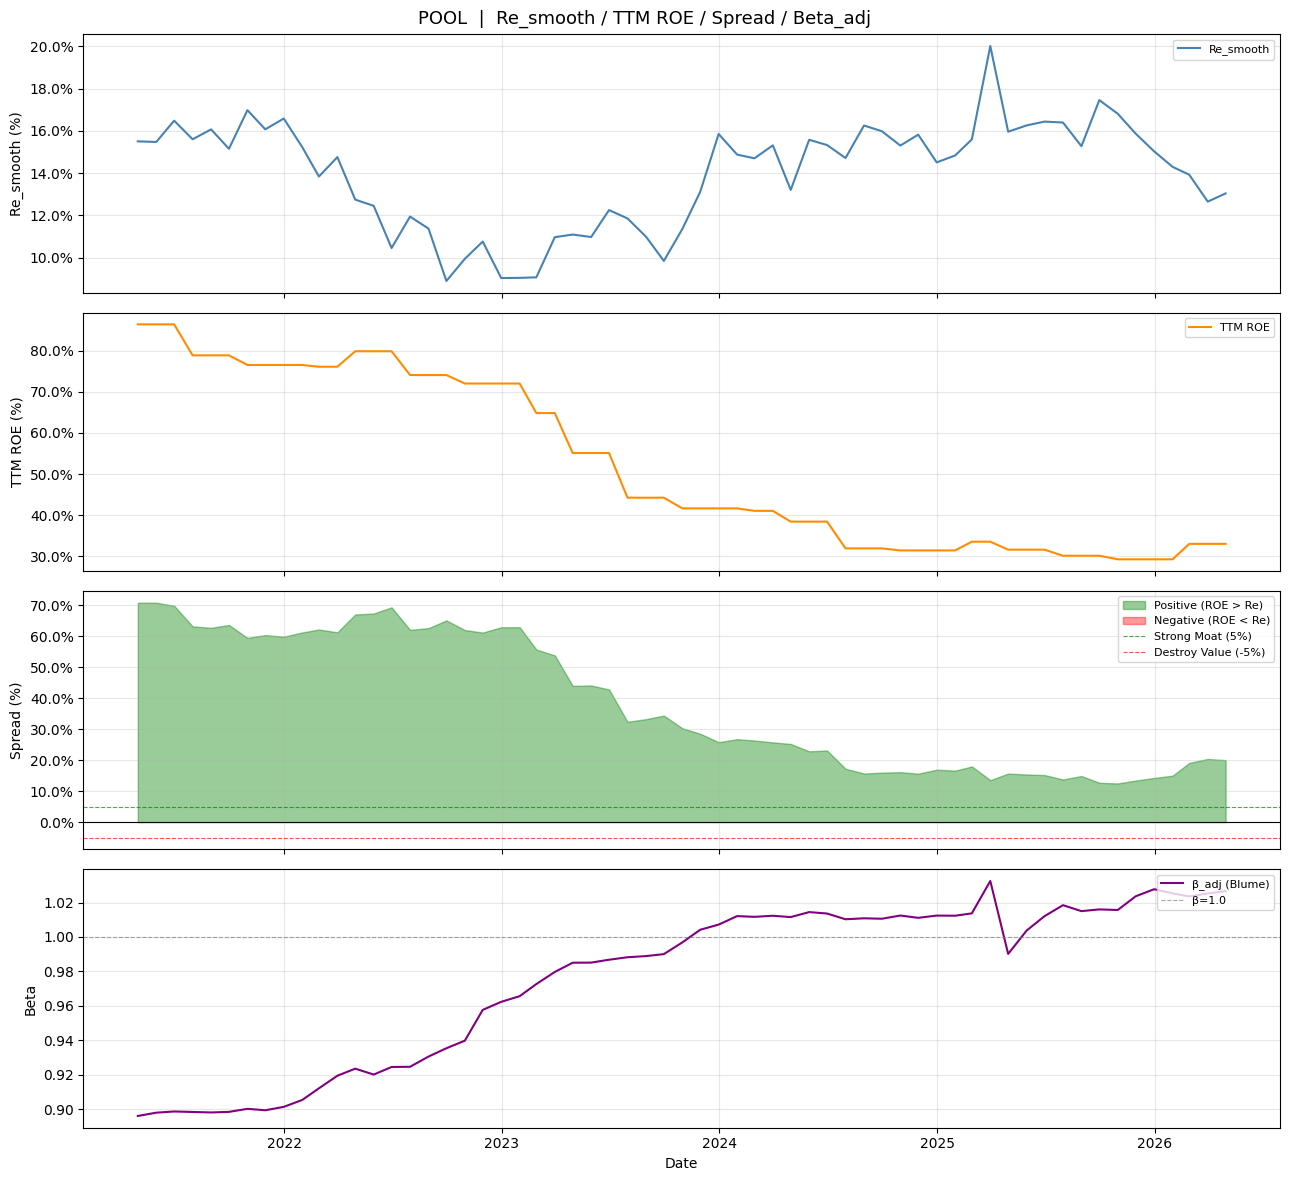


[VSAT] 최신 데이터 (2026-04-30):
  Re_smooth            = 16.07%
  roe                  = -7.27%
  rim_spread_smooth    = -23.34%
  beta_adj             = 1.3699


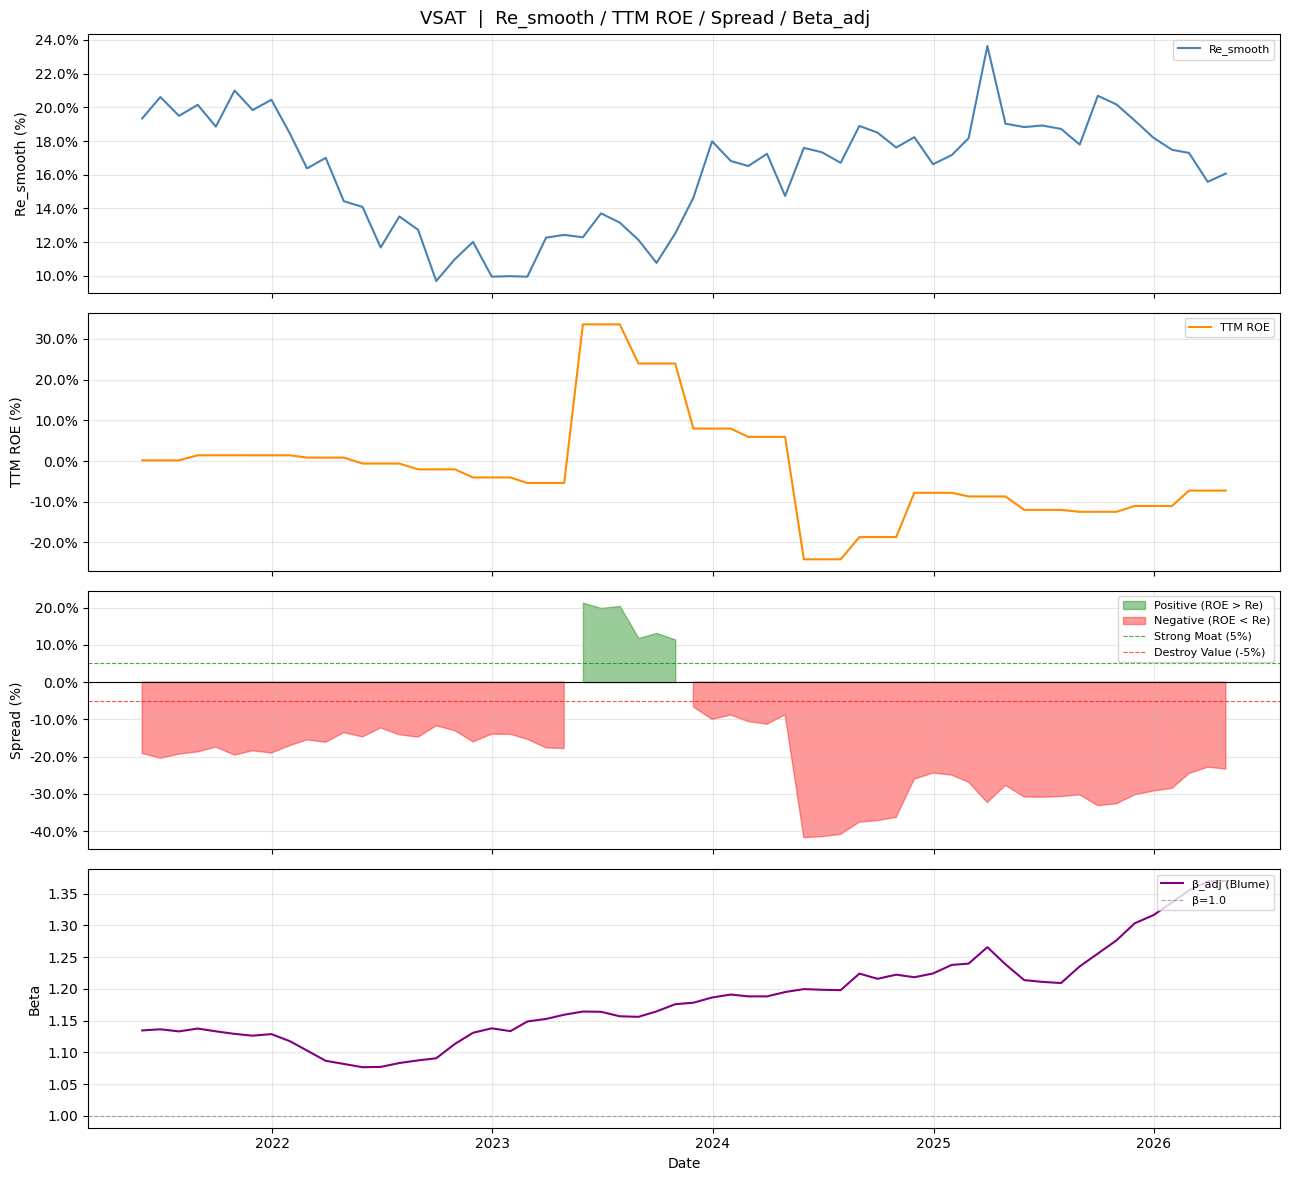


[KLAC] 최신 데이터 (2026-04-30):
  Re_smooth            = 17.34%
  roe                  = 100.73%
  rim_spread_smooth    = 83.39%
  beta_adj             = 1.5128


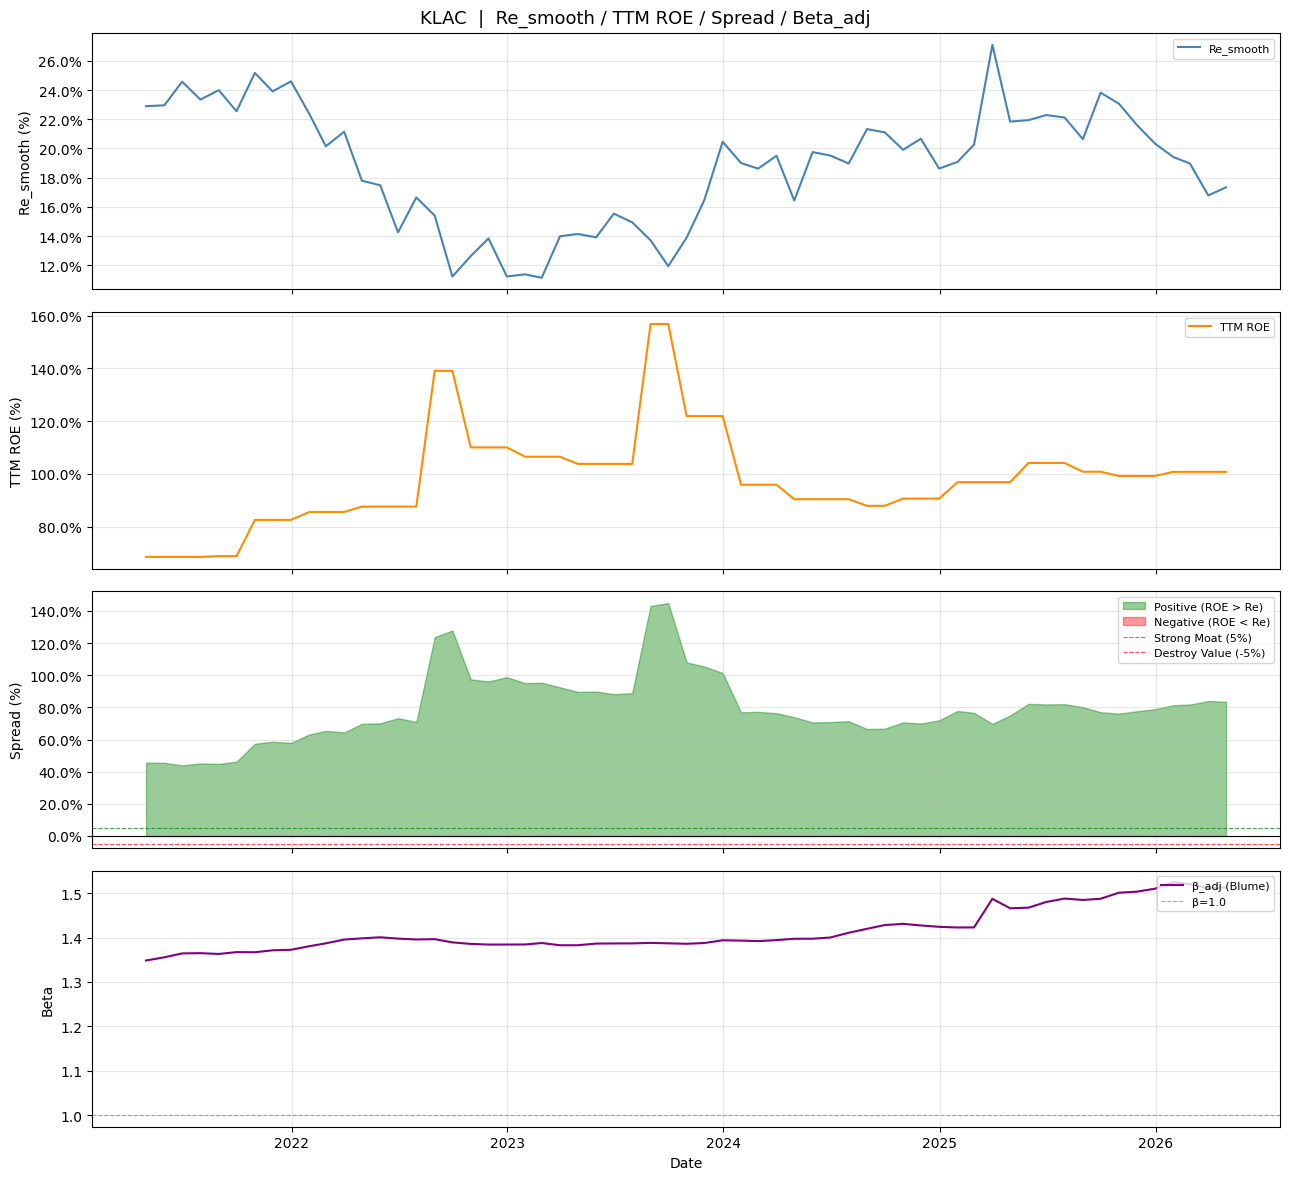


[LLY] 최신 데이터 (2026-04-30):
  Re_smooth            = 10.41%
  roe                  = 101.35%
  rim_spread_smooth    = 90.94%
  beta_adj             = 0.7295


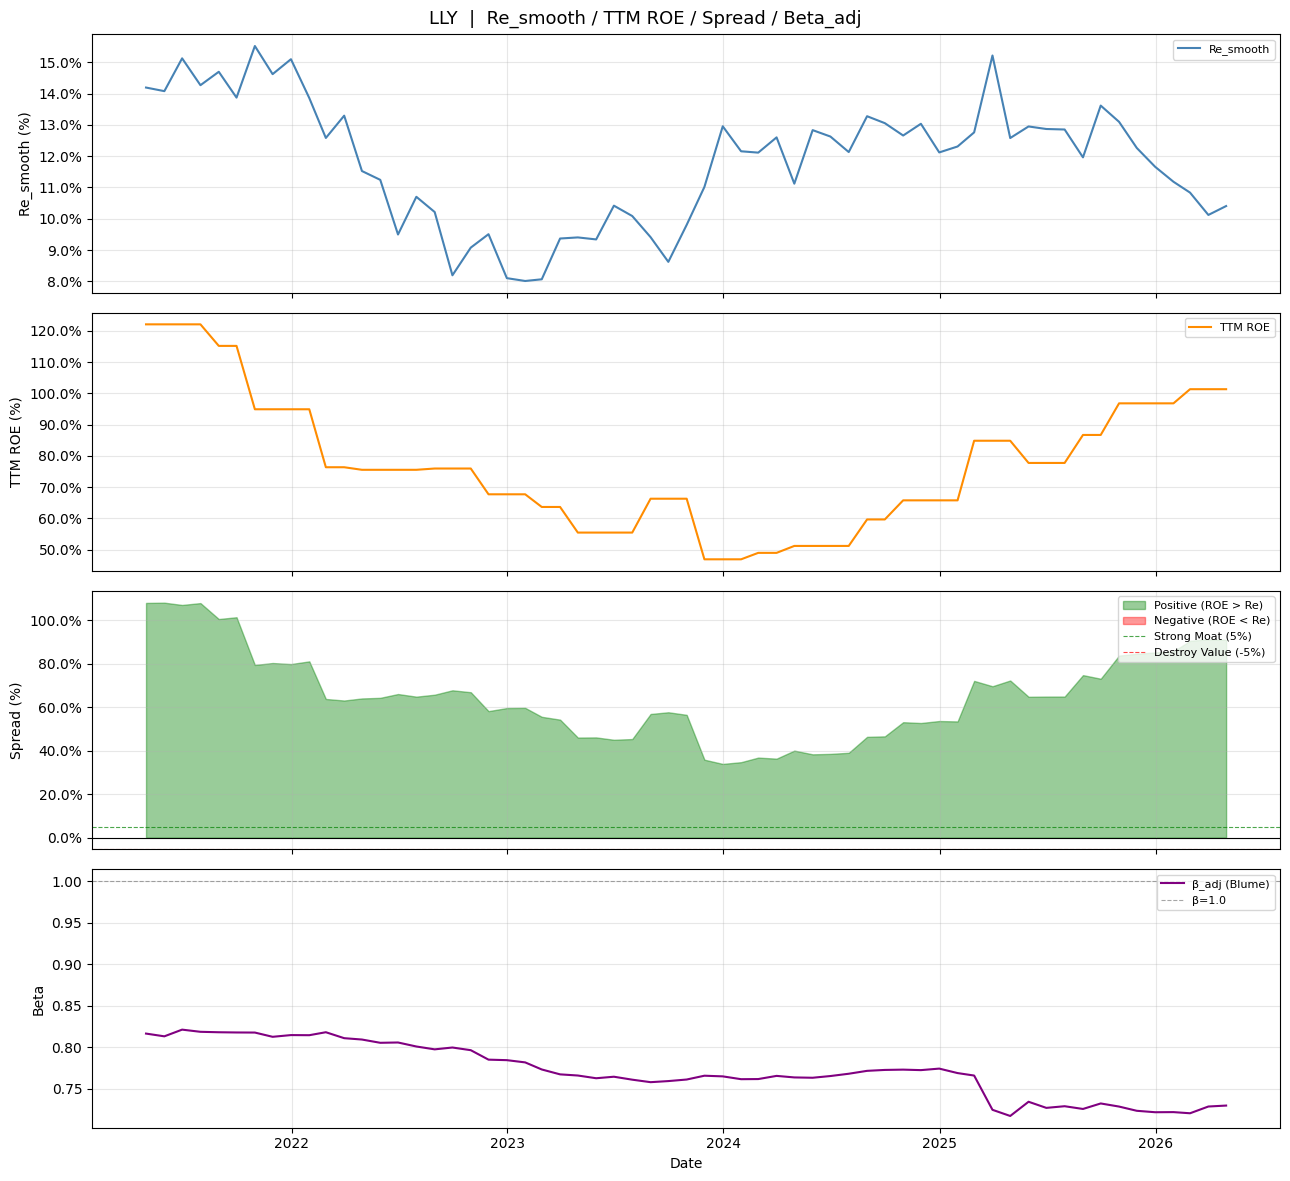


[MU] 최신 데이터 (2026-04-30):
  Re_smooth            = 17.34%
  roe                  = 39.83%
  rim_spread_smooth    = 22.49%
  beta_adj             = 1.5124


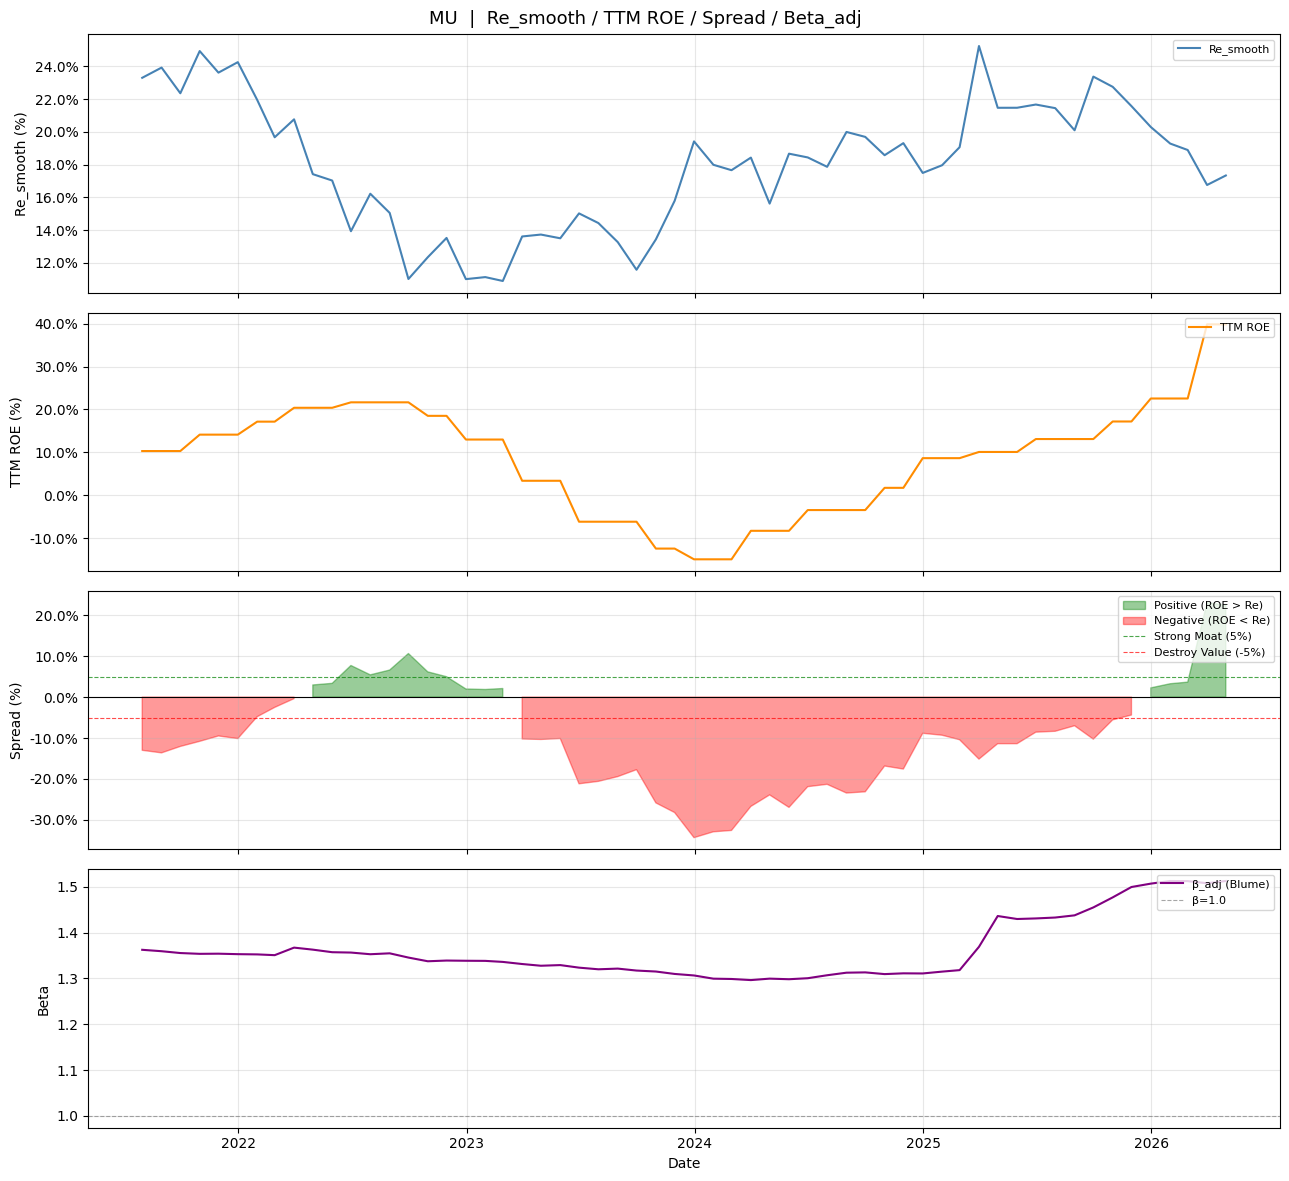


[해자 분류 요약]


,ticker,avg_spread_pct,moat_grade
0,RNG,43084.69,strong_economic_moat
1,HD,3968.29,strong_economic_moat
2,RVNC,2879.42,strong_economic_moat
3,COR,1945.68,strong_economic_moat
4,CCU,1839.51,strong_economic_moat
...,...,...,...
1944,CTGO,-1197.56,weak
1945,PRO,-1865.83,weak
1946,GRPN,-1887.41,weak
1947,ICPT,-7657.06,weak


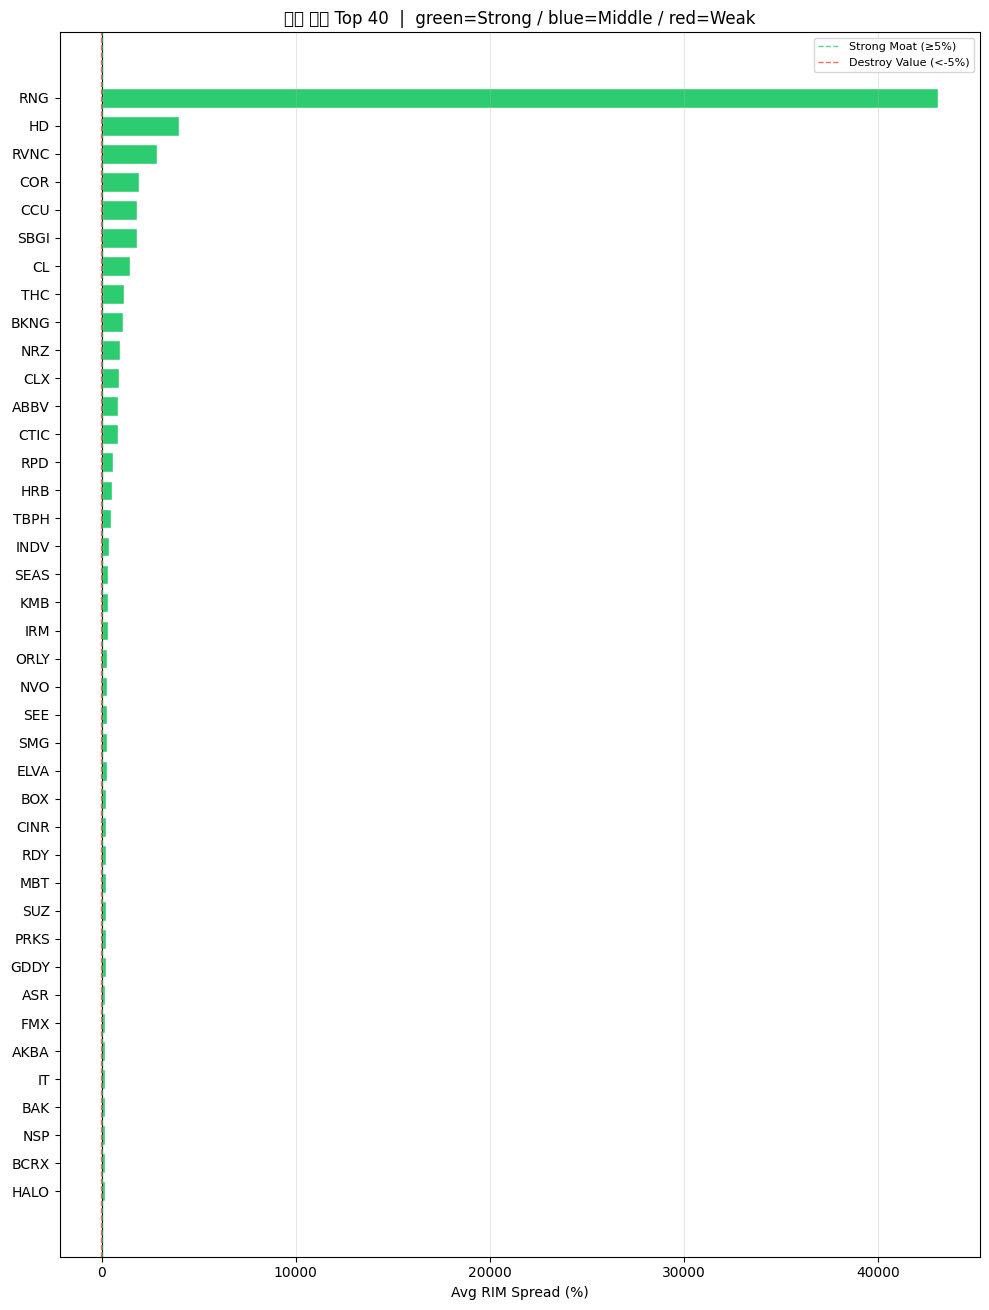


  Strong Moat (≥5%)     :  493개  ['RNG', 'HD', 'RVNC', 'COR', 'CCU', 'SBGI', 'CL', 'THC', 'BKNG', 'NRZ', 'CLX', 'ABBV', 'CTIC', 'RPD', 'HRB']...
  Middle      (0~5%)    :  240개  ['PNR', 'MHO', 'FBIN', 'HWKN', 'WNS', 'USLM', 'IPAR', 'GOL', 'MKC', 'LSCC', 'WMB', 'RSG', 'CNQ', 'IMO', 'REGI']...
  Weak        (<0%)     : 1216개  ['ACTG', 'HAE', 'EURN', 'COLM', 'IBA', 'AKAM', 'TX', 'W', 'DHT', 'SEB', 'POST', 'URBN', 'SB', 'BDC', 'CAH']...


In [77]:
# ─────────────────────────────────────────────────────────────────
# Cell 15 · 분석 실행 & DB 현황 조회
# ─────────────────────────────────────────────────────────────────

# ── 시각화 대상 티커 (원하는 종목으로 변경) ─────────────────────
PLOT_TICKERS = ["POOL", "VSAT", "KLAC", "LLY", "MU"]

# ── DB에서 spread 데이터 조회 (wide-format) ─────────────────────
def load_spread_from_db(
    tickers:    Optional[List[str]] = None,
    start_date: Optional[str]       = None,
) -> pd.DataFrame:
    """
    us_rim_spread_data → wide-format
    [date, ticker, Re_smooth, beta_adj, roe, rim_spread_smooth]
    ★ cursor.execute → fetchall → DataFrame 패턴 유지
    """
    where  = ["indicator IN ('Re_smooth','beta_adj','roe_ttm','rim_spread_smooth')"]
    params: List[Any] = []
    if start_date:
        where.append("date >= %s"); params.append(start_date)
    if tickers:
        ph = ",".join(["%s"] * len(tickers))
        where.append(f"ticker IN ({ph})"); params.extend(tickers)

    sql = (f"SELECT date, ticker, indicator, value FROM {TABLE_RESULT} "
           f"WHERE {' AND '.join(where)} ORDER BY ticker, date, indicator")

    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql, params)
            rows = cur.fetchall()
            long = pd.DataFrame(rows)    # ★ pd.read_sql 사용 안 함
    finally:
        conn.close()

    if long.empty:
        return pd.DataFrame()

    long["date"] = pd.to_datetime(long["date"])
    wide = long.pivot_table(index=["date", "ticker"],
                            columns="indicator", values="value")
    wide.columns.name = None
    wide = wide.reset_index()
    wide = wide.rename(columns={"roe_ttm": "roe"})
    return wide.sort_values(["ticker", "date"]).reset_index(drop=True)


# ════════════════════════════════════════════════════════════════
# ① DB 현황 요약
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print(f"[DB 현황] {TABLE_RESULT}")
print("=" * 65)
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(
            f"SELECT indicator, "
            f"COUNT(DISTINCT ticker) AS tickers, "
            f"COUNT(*) AS total_rows, "
            f"MIN(date) AS date_from, "
            f"MAX(date) AS date_to "
            f"FROM {TABLE_RESULT} GROUP BY indicator ORDER BY indicator"
        )
        _summary = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

if _summary.empty:
    print("  데이터 없음 — Cell 13 (배치 실행) 을 먼저 실행하세요.")
else:
    display(_summary)

# ════════════════════════════════════════════════════════════════
# ② 개별 티커 시각화
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print(f"[시각화] 대상: {PLOT_TICKERS}")
print("=" * 65)

spread_data = load_spread_from_db(tickers=PLOT_TICKERS, start_date="2018-01-01")
if spread_data.empty:
    print("[INFO] 시각화할 데이터 없음 — 배치 실행 후 재시도하세요.")
else:
    print(f"  로드: {len(spread_data):,}행  "
          f"({spread_data['date'].min().date()} ~ {spread_data['date'].max().date()})")
    for tk in PLOT_TICKERS:
        if tk in spread_data["ticker"].values:
            sub = spread_data[spread_data["ticker"] == tk]
            latest = sub.iloc[-1]
            print(f"\n[{tk}] 최신 데이터 ({pd.to_datetime(latest['date']).date()}):")
            for col in ["Re_smooth", "roe", "rim_spread_smooth", "beta_adj"]:
                if col in latest.index and not pd.isna(latest[col]):
                    print(f"  {col:20s} = {latest[col]*100:.2f}%"
                          if col != "beta_adj"
                          else f"  {col:20s} = {latest[col]:.4f}")
            plot_spread(spread_data, tk)
        else:
            print(f"  [SKIP] {tk}: DB 데이터 없음")

# ════════════════════════════════════════════════════════════════
# ③ 해자 분류 요약
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("[해자 분류 요약]")
print("=" * 65)

# 전체 티커 로드 (해자 분류는 모든 티커 대상)
all_spread = load_spread_from_db()
if not all_spread.empty:
    moat = classify_moat(all_spread)
    display(moat)
    plot_moat_summary(moat)

    print()
    for grade, label in [
        ("strong_economic_moat", "Strong Moat (≥5%)"),
        ("middle",               "Middle      (0~5%)"),
        ("weak",                 "Weak        (<0%) "),
    ]:
        g = moat[moat["moat_grade"] == grade]
        print(f"  {label:22s}: {len(g):>4}개  {g['ticker'].tolist()[:15]}"
              f"{'...' if len(g) > 15 else ''}")
else:
    print("[INFO] 해자 분류 데이터 없음 — 배치 실행 후 재시도하세요.")
